In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import os, pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

PROJECT_DIR = "/content/drive/MyDrive/Concrete_defects_CNN_v2"
DATA_DIR = os.path.join(PROJECT_DIR, "Data")
DATASET_DIR = os.path.join(DATA_DIR, "dacl1k_raw")

assert os.path.exists(DATASET_DIR), f"{DATASET_DIR} not found — run 01_dataset_download.ipynb first."
print("Using dataset at:", DATASET_DIR)


Mounted at /content/drive
Using dataset at: /content/drive/MyDrive/Concrete_defects_CNN_v2/Data/dacl1k_raw


In [ ]:
csv_candidates = [f for f in os.listdir(DATASET_DIR) if f.endswith(".csv")]
print("CSV files found:", csv_candidates)
assert csv_candidates, "No CSV found in DATASET_DIR — check its contents."

LABELS_CSV = os.path.join(DATASET_DIR, "annotations_v1.csv")
assert os.path.exists(LABELS_CSV), f"{LABELS_CSV} not found"
df = pd.read_csv(LABELS_CSV)
print(f"Loaded {LABELS_CSV}")
print("Shape:", df.shape)
df.head()


CSV files found: ['annotations_v1.csv', 'annotations_clean.csv']
Loaded /content/drive/MyDrive/Concrete_defects_CNN_v2/Data/dacl1k_raw/annotations_v1.csv
Shape: (1474, 11)


,img_path,img_name,NoDamage,Crack,Efflorescence,Rust,Spallation,BarsExposed,CLASSES_STRING,CLASSES_N,split_type
0,dacl1k/v1/14_001915.jpg,14_001915.jpg,0,0,0,2,0,0,R,2,train
1,dacl1k/v1/06_000043.jpg,06_000043.jpg,1,0,0,0,0,0,N,1,train
2,dacl1k/v1/17_000084.jpg,17_000084.jpg,1,0,0,0,0,0,N,1,train
3,dacl1k/v1/06_000213.jpg,06_000213.jpg,0,0,0,1,0,0,R,1,train
4,dacl1k/v1/06_000223.jpg,06_000223.jpg,0,1,0,0,0,0,C,1,train


In [ ]:
print(df.columns.tolist())

['img_path', 'img_name', 'NoDamage', 'Crack', 'Efflorescence', 'Rust', 'Spallation', 'BarsExposed', 'CLASSES_STRING', 'CLASSES_N', 'split_type']


In [ ]:
print("All columns:", df.columns.tolist())

# Explicit known non-label / metadata columns for dacl1k
known_meta_cols = {"img_name", "img_path", "CLASSES", "CLASSES_N", "CLASSES_STRING",
                    "isStatusChanged", "split", "split_bikit", "split_type",
                    "N_Classes", "n_classes", "num_labels"}

label_cols = [c for c in df.columns
              if c not in known_meta_cols and pd.api.types.is_numeric_dtype(df[c])]

# Search for any column with "split" in its name (case-insensitive), instead of exact match
split_candidates = [c for c in df.columns if "split" in c.lower()]
split_col = split_candidates[0] if split_candidates else None

path_col = "img_path" if "img_path" in df.columns else "img_name"

print("Detected label columns:", label_cols)
print("Detected split column:", split_col, "| all split-like candidates:", split_candidates)
print("Detected image-path column:", path_col)

if split_col is None:
    print("\nNo split column found automatically. Unique values from likely candidates:")
    for c in df.columns:
        if df[c].dtype == object and df[c].nunique() <= 10:
            print(f"  {c}: {df[c].unique()}")
    raise AssertionError("Could not find a split column — look at the printed candidates above, "
                          "then set split_col = \"<the right column name>\" manually and re-run.")


All columns: ['img_path', 'img_name', 'NoDamage', 'Crack', 'Efflorescence', 'Rust', 'Spallation', 'BarsExposed', 'CLASSES_STRING', 'CLASSES_N', 'split_type']
Detected label columns: ['NoDamage', 'Crack', 'Efflorescence', 'Rust', 'Spallation', 'BarsExposed']
Detected split column: split_type | all split-like candidates: ['split_type']
Detected image-path column: img_path


In [ ]:
for col in label_cols:
    print(col, sorted(df[col].dropna().unique())[:20])

NoDamage [np.int64(0), np.int64(1), np.int64(2)]
Crack [np.int64(0), np.int64(1), np.int64(2)]
Efflorescence [np.int64(0), np.int64(1)]
Rust [np.int64(0), np.int64(1), np.int64(2)]
Spallation [np.int64(0), np.int64(1)]
BarsExposed [np.int64(0), np.int64(1)]


In [ ]:
for col in label_cols:
    print("\n", col)
    print(df[df[col] == 2][[col, "CLASSES_STRING"]].head(10))


 NoDamage
      NoDamage CLASSES_STRING
1158         2              N

 Crack
      Crack CLASSES_STRING
143       2            CES
144       2            CES
244       2            CES
687       2            CES
740       2            CES
755       2            CES
1114      2            CES
1445      2           CESR
1447      2           CESR

 Efflorescence
Empty DataFrame
Columns: [Efflorescence, CLASSES_STRING]
Index: []

 Rust
    Rust CLASSES_STRING
0      2              R
9      2              R
10     2             SR
13     2              R
19     2            BSR
40     2              R
59     2              R
60     2              R
65     2              R
69     2            BSR

 Spallation
Empty DataFrame
Columns: [Spallation, CLASSES_STRING]
Index: []

 BarsExposed
Empty DataFrame
Columns: [BarsExposed, CLASSES_STRING]
Index: []


In [ ]:
print("Rows with missing CLASSES_STRING:", df["CLASSES_STRING"].isna().sum())


Rows with missing CLASSES_STRING: 0


In [ ]:
print(df[label_cols].value_counts().head(20))
print("\nCLASSES_STRING values:")
print(df["CLASSES_STRING"].value_counts())

NoDamage  Crack  Efflorescence  Rust  Spallation  BarsExposed
1         0      0              0     0           0              221
0         0      0              1     0           0              214
                                0     1           0              149
          1      0              0     0           0              131
          0      1              0     0           0              116
                 0              1     1           1               97
          1      1              0     0           0               76
          0      0              1     1           0               69
                                2     0           0               59
          1      1              0     1           0               41
                 0              0     1           0               37
          0      1              1     0           0               36
          1      0              1     0           0               31
          0      0              1     0  

In [ ]:
label_mapping = {
    "NoDamage": "N",
    "Crack": "C",
    "Efflorescence": "E",
    "Rust": "R",
    "Spallation": "S",
    "BarsExposed": "B"
}

for col, code in label_mapping.items():
    df[col] = df["CLASSES_STRING"].fillna("").str.contains(code, regex=False).astype("float32")

print(df[label_cols].head())
print("\nUnique values after conversion:")
for col in label_cols:
    print(col, sorted(df[col].unique()))

   NoDamage  Crack  Efflorescence  Rust  Spallation  BarsExposed
0       0.0    0.0            0.0   1.0         0.0          0.0
1       1.0    0.0            0.0   0.0         0.0          0.0
2       1.0    0.0            0.0   0.0         0.0          0.0
3       0.0    0.0            0.0   1.0         0.0          0.0
4       0.0    1.0            0.0   0.0         0.0          0.0

Unique values after conversion:
NoDamage [np.float32(0.0), np.float32(1.0)]
Crack [np.float32(0.0), np.float32(1.0)]
Efflorescence [np.float32(0.0), np.float32(1.0)]
Rust [np.float32(0.0), np.float32(1.0)]
Spallation [np.float32(0.0), np.float32(1.0)]
BarsExposed [np.float32(0.0), np.float32(1.0)]


In [ ]:
print(f"Total images: {len(df)}")
print()
print("Split sizes:")
print(df[split_col].value_counts())


Total images: 1474

Split sizes:
split_type
train    1101
test      219
val       154
Name: count, dtype: int64


In [ ]:
CLEAN_CSV = os.path.join(DATASET_DIR, "annotations_clean.csv")
df.to_csv(CLEAN_CSV, index=False)

Rust             667.0
Spallation       519.0
Efflorescence    383.0
Crack            381.0
NoDamage         222.0
BarsExposed      195.0
dtype: float32


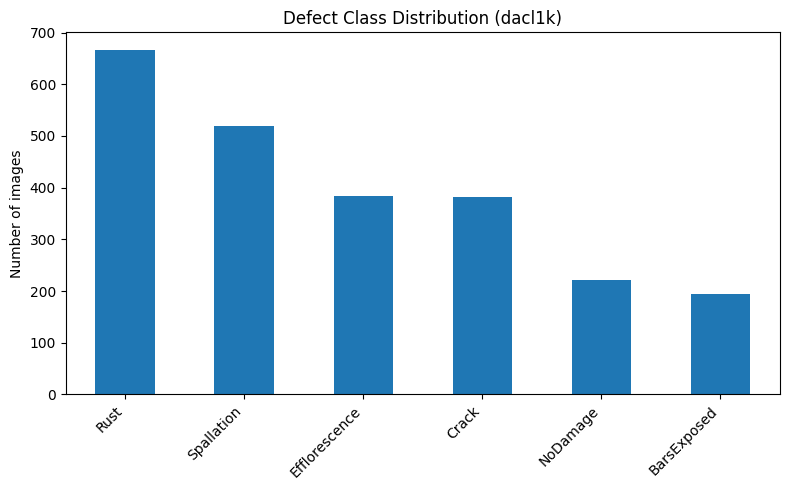

In [ ]:
class_counts = df[label_cols].sum().sort_values(ascending=False)
print(class_counts)

class_counts.plot(kind="bar", figsize=(8, 5))
plt.title("Defect Class Distribution (dacl1k)")
plt.ylabel("Number of images")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [ ]:
df["num_labels"] = df[label_cols].sum(axis=1)
print("Labels per image:")
print(df["num_labels"].value_counts().sort_index())
print(f"Mean labels per image: {df['num_labels'].mean():.2f}")


Labels per image:
num_labels
1.0    891
2.0    321
3.0    217
4.0     42
5.0      3
Name: count, dtype: int64
Mean labels per image: 1.61


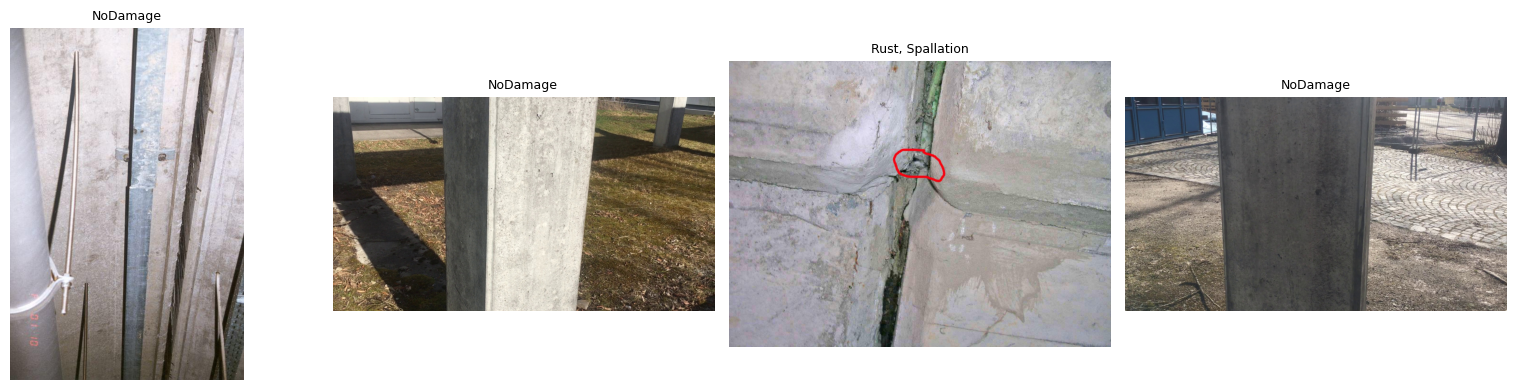

In [ ]:
def resolve_image_path(dataset_dir, rel_path):
    """Try the path as given; if not found, strip a redundant leading
    dataset-name folder (e.g. 'dacl1k/v1/x.jpg' -> 'v1/x.jpg') and try again."""
    candidate = os.path.join(dataset_dir, rel_path)
    if os.path.exists(candidate):
        return candidate
    parts = rel_path.split("/", 1)
    if len(parts) == 2:
        stripped_candidate = os.path.join(dataset_dir, parts[1])
        if os.path.exists(stripped_candidate):
            return stripped_candidate
    return candidate  # return original so the error message below is honest

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
sample_rows = df.sample(n=4, random_state=42)
for ax, (_, row) in zip(axes, sample_rows.iterrows()):
    img_path = resolve_image_path(DATASET_DIR, row[path_col])
    try:
        img = Image.open(img_path).convert("RGB")
        ax.imshow(img)
    except Exception:
        ax.text(0.5, 0.5, f"missing:\n{img_path}", ha="center", va="center")
    active_labels = [c for c in label_cols if row[c] == 1]
    ax.set_title(", ".join(active_labels) if active_labels else "none", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()
